<a href="https://colab.research.google.com/github/ShivaniAnand424/Complete-Python-3-Bootcamp/blob/master/ShivaniAnand_14_SPL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [106]:
df = pd.read_csv('/content/drive/MyDrive/Students Social Media Addiction.csv')
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


# **EDA**


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [108]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [109]:
df.shape

(705, 13)

In [110]:
age = df['Age']

In [111]:
age.describe()

,Age
count,705.000000
mean,20.659574
std,1.399217
min,18.000000
25%,19.000000
50%,21.000000
75%,22.000000
max,24.000000


Target Variable Analysis (EDA)

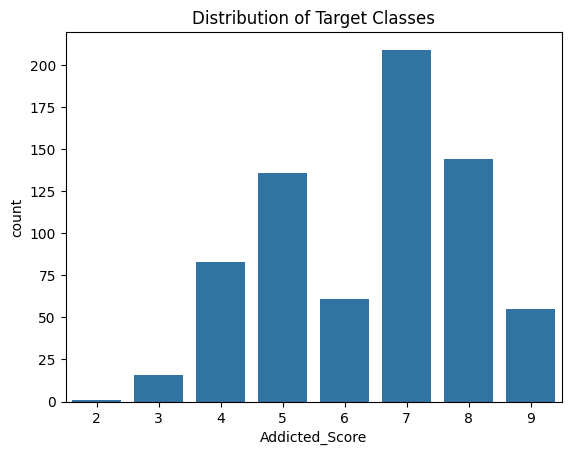

In [112]:
sns.countplot(x='Addicted_Score', data=df)
plt.title('Distribution of Target Classes')
plt.show()

Correlation [tells abount which numerical data is stronger related to each other target]

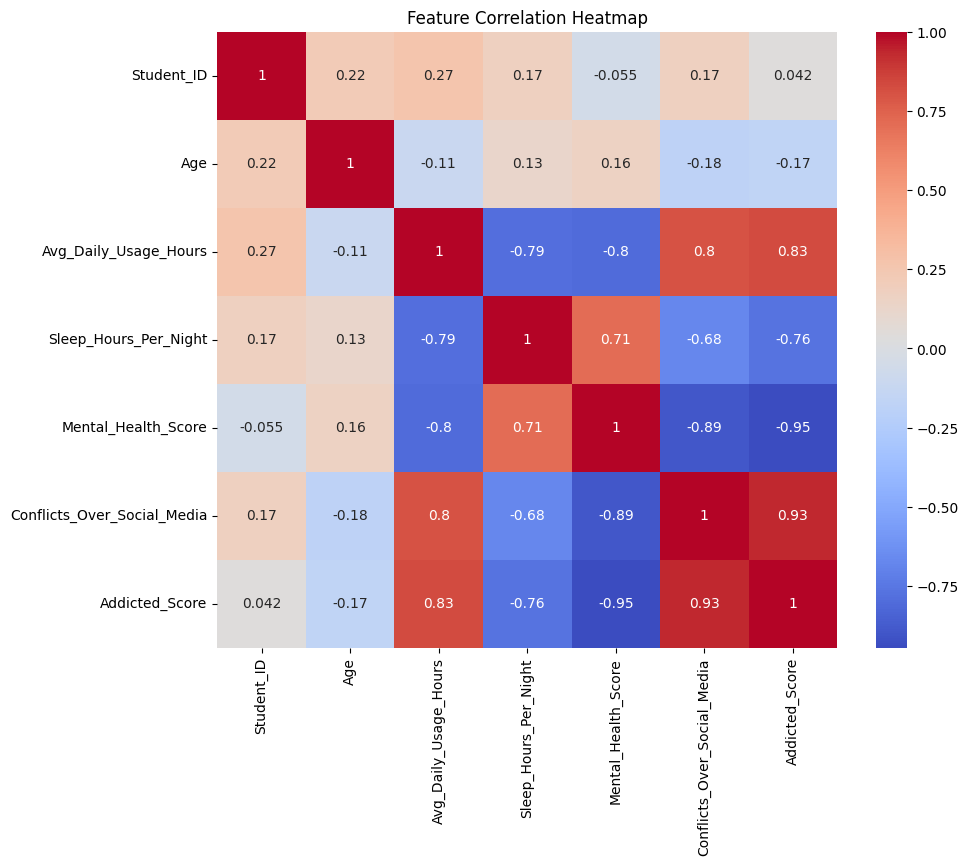

In [113]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Outliers (best is boxplot)

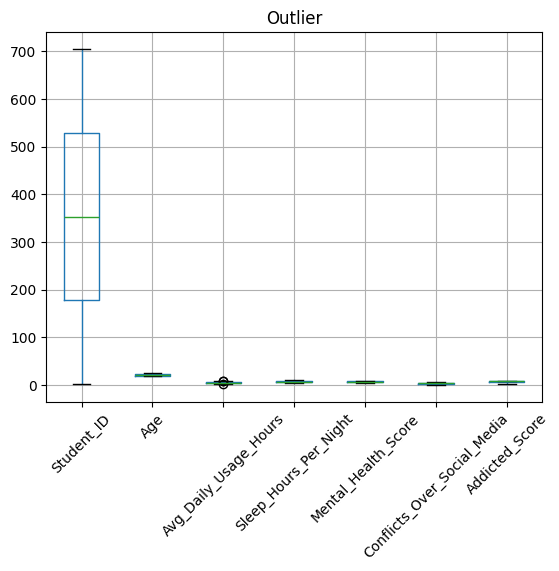

In [114]:
numerical_cols = df.select_dtypes(include=['number']).columns
df[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Outlier')
plt.show()

Categorical Feature Impact

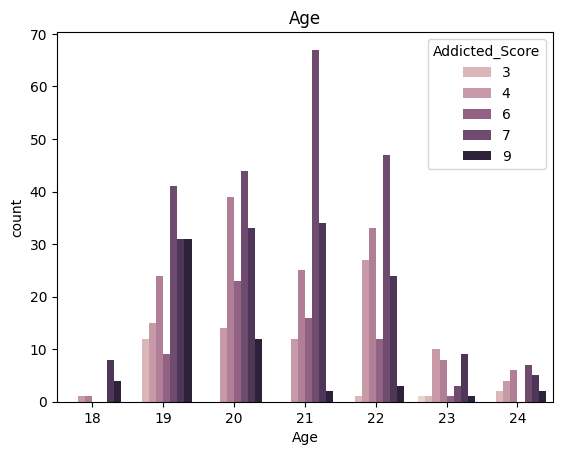

In [115]:
sns.countplot(x='Age', hue='Addicted_Score', data=df)
plt.title('Age')
plt.show()

# **1) Data preprocessing Output**

Handling Missing Values

In [116]:
df = df.drop('Student_ID', axis=1) #student id is unique to every person

In [117]:
df.isnull().sum()

,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0
Relationship_Status,0


**Encoding**

In [118]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Affects_Academic_Performance'] = le.fit_transform(df['Affects_Academic_Performance']) #Target y(yes/no)
df = pd.get_dummies(df, columns=['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Relationship_Status', 'Conflicts_Over_Social_Media'], drop_first=True) #feature x (catogorical to numerical data)

In [119]:
from sklearn.model_selection import train_test_split

X = df.drop('Affects_Academic_Performance', axis=1)
y = df['Affects_Academic_Performance']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Feature Scaling**

In [120]:
from sklearn.preprocessing import StandardScaler
X = df.drop('Affects_Academic_Performance', axis=1)
y = df['Affects_Academic_Performance']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_preprocessing_output = pd.DataFrame(X_scaled, columns=X.columns)
print(X_preprocessing_output.head())

        Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
0 -1.186915               0.223857              -0.327638   
1  0.958662              -2.243309               0.560423   
2 -0.471723               0.860545              -1.659730   
3 -1.902108              -1.527035               0.116393   
4  0.243470              -0.333245              -0.771668   

   Mental_Health_Score  Addicted_Score  Gender_Male  \
0            -0.205520        0.985550    -0.998583   
1             1.605628       -2.166958     1.001419   
2            -1.111095        1.616052    -0.998583   
3             0.700054       -1.536456     1.001419   
4            -0.205520        0.355048     1.001419   

   Academic_Level_High School  Academic_Level_Undergraduate  Country_Albania  \
0                   -0.199557                      0.998583        -0.037689   
1                   -0.199557                     -1.001419        -0.037689   
2                   -0.199557                      0.998583   

# **2)Model comparison table**

In [121]:
!pip install xgboost

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [123]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "xgboost": XGBClassifier()
}

In [124]:
from sklearn.model_selection import train_test_split

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train) #trained model using scaled data
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results.append([name, acc, prec, rec, f1])

In [125]:
# create data frame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
# Display
print(results_df)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression  1.000000   1.000000     1.0  1.000000
1        Random Forest  1.000000   1.000000     1.0  1.000000
2                  SVM  0.957447   0.935484     1.0  0.966667
3              xgboost  1.000000   1.000000     1.0  1.000000


**Accuracy**

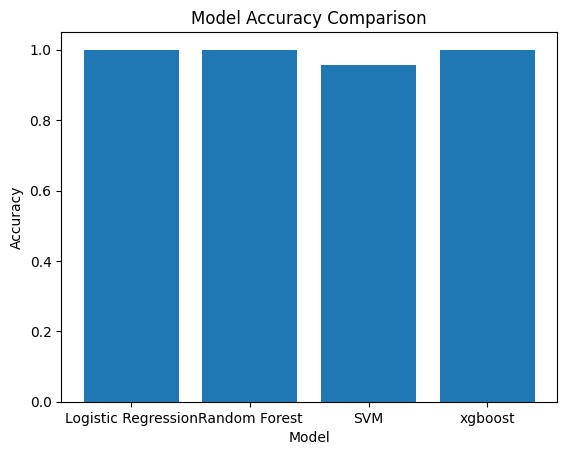

In [126]:
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

Precision-Recall Curve

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0
SVM Accuracy: 1.0
xgboost Accuracy: 1.0


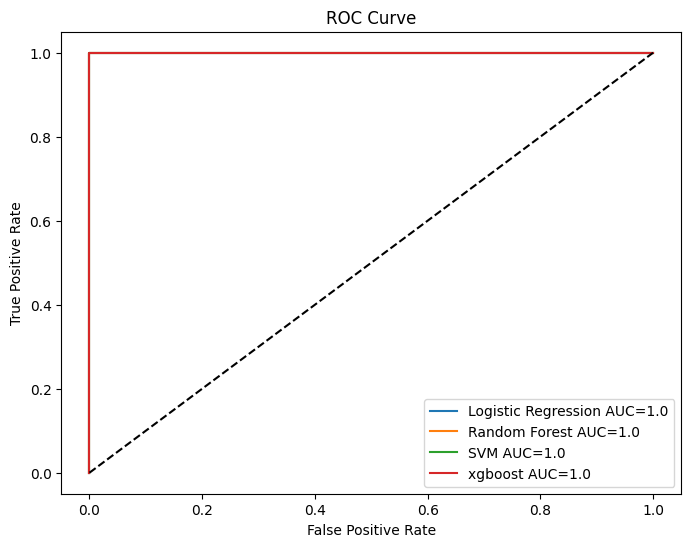

In [127]:
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))

for n, m in models.items():
    X1 = X.copy()

    if 'Academic_Level' in X1.columns:
        X1['Academic_Level'] = pd.to_numeric(
            X1['Academic_Level'], errors='coerce'
        ).fillna(0).astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X1, y, test_size=0.25, random_state=7
    )

    if "Random Forest" in n or "XGBoost" in n:
        m.set_params(n_estimators=50, max_depth=5, random_state=7)
    elif "SVM" in n:
        m.set_params(probability=True, random_state=7) #probability true to show roc
    else:
        try:
            m.set_params(random_state=7)
        except:
            pass

    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    c = 0
    t = len(y_test)
    for i in range(t):
        if y_pred[i] == y_test.iloc[i]:
            c += 1

    acc = c / t
    print(n, "Accuracy:", round(acc, 2))

    if hasattr(m, "predict_proba"):
        y_prob = m.predict_proba(X_test)[:, 1]
    elif hasattr(m, "decision_function"):
        y_prob = m.decision_function(X_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    a = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=n + " AUC=" + str(round(a, 2)))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# **4) Confusion matrix**

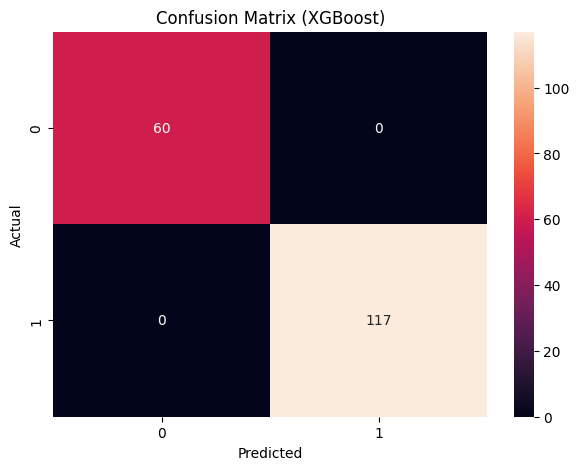

In [128]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = m.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (XGBoost)')
plt.show()

# **5) Best model selection : XGBoost [Handling Non-Linearity,Regularization,Feature Importance]**

# **6) GUI interface**

In [129]:
import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(m, f) #m is your trained xgboost model from the loop
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Model and Scaler saved")

Model and Scaler saved


Hybrid Voting

In [132]:
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
import gradio as gr
import numpy as np

gui_columns = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
X_gui = df[gui_columns]
y_gui = df['Affects_Academic_Performance']

X_train_gui, X_test_gui, y_train_gui, y_test_gui = train_test_split(X_gui, y_gui, test_size=0.2, random_state=7)

scaler_gui = StandardScaler()
X_train_scaled_gui = scaler_gui.fit_transform(X_train_gui)

hybrid_model_gui = VotingClassifier( #train hybried model
    estimators=[('lr', LogisticRegression()), ('svm', SVC(probability=True)), ('xgb', XGBClassifier())],
    voting='soft'
)
hybrid_model_gui.fit(X_train_scaled_gui, y_train_gui)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('svm', SVC(probability=True)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [133]:
def predict_student_impact(age, usage, sleep, mental):
    try:
        features = np.array([[age, usage, sleep, mental]])
        features_scaled = scaler_gui.transform(features)

        prediction = hybrid_model_gui.predict(features_scaled)

        return "HIGH RISK" if prediction[0] == 1 else "LOW RISK"

    except Exception as e:
        return f"Error: {str(e)}"

interface = gr.Interface(
    fn=predict_student_impact,
    inputs=[gr.Number(label="Age"), gr.Number(label="Usage"), gr.Number(label="Sleep"), gr.Number(label="Mental Health")],
    outputs="text"
)
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7e66906cb43b18dfbb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
